In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import TruncatedUnknownVarianceMSE

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from sklearn.linear_model import LinearRegression

ch.set_printoptions(precision=4, sci_mode=False)

In [2]:
def trunc_mse(pred, targ, lambda_, phi, seed=69): 
    if seed is not None:
        ch.manual_seed(seed)
    lambda_.requires_grad = True
    pred.requires_grad = True
    loss = TruncatedUnknownVarianceMSE.apply(pred, targ, lambda_, phi)
    loss = loss.sum(0)
    loss.backward()
    return loss, pred.grad, lambda_.grad

In [3]:
W = ch.ones(1)
print(f'groud truth W:\n {W}')

X = ch.rand(1000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 1000
W fit:
 [0.94083875]


In [4]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.686
trunc lin reg W:
 [[1.5672929]]


<IPython.core.display.Javascript object>


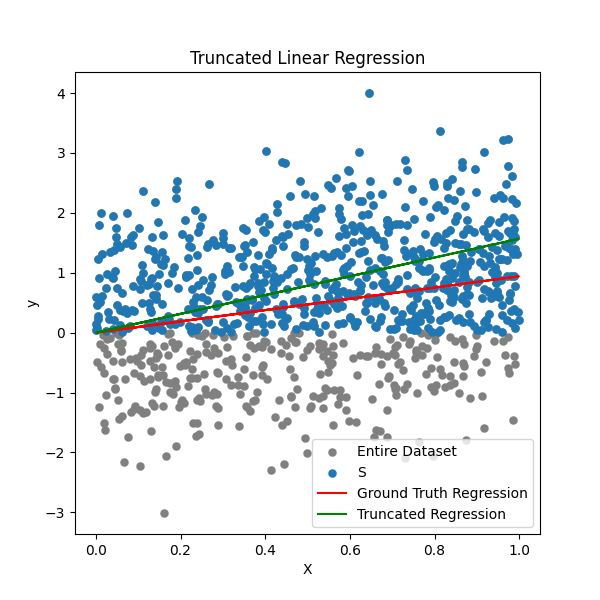

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc, Y_trunc, linewidths=.1, label='S')
ax.plot(X.sort()[0], gt_lin_reg.predict(X.sort()[0]), color='red', label='Ground Truth Regression')
ax.plot(X.sort()[0], trunc_lin_reg.predict(X.sort()[0]), color='green', label='Truncated Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated Linear Regression')
ax.legend()
plt.show()

# Vary w

<IPython.core.display.Javascript object>


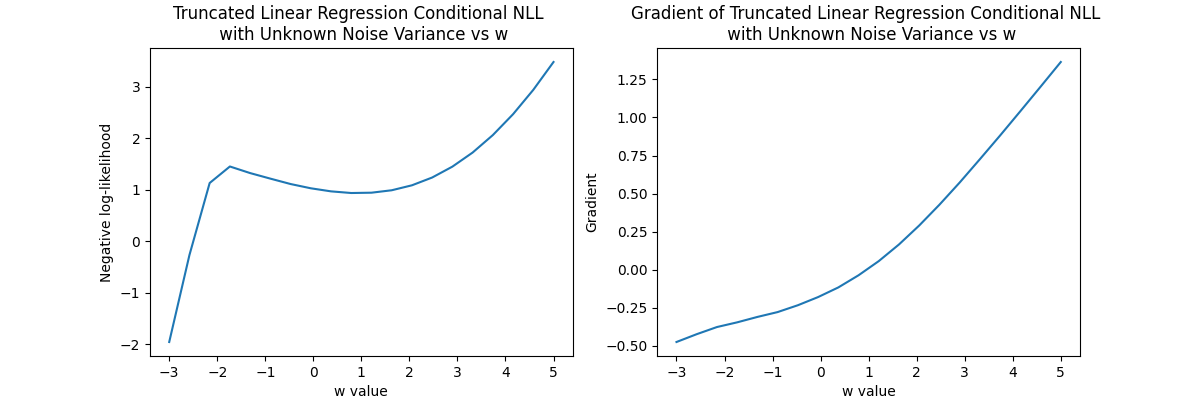

In [6]:
ws = ch.linspace(-3, 5, 20)

losses = ch.Tensor([])
grads = ch.Tensor([])

for w in ws: 
    loss, pred_grad, lambda_grad = trunc_mse(X_trunc @ w.reshape(1, 1), Y_trunc, ch.ones(1, 1), phi)
    losses = ch.cat([losses, loss[...,None].mean(0).detach()])
    grads = ch.cat([grads, (pred_grad * X_trunc).sum(0)])
    
# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ws, losses)
ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs w")

ax2.plot(ws, grads)
ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs w")

plt.show()

# Vary Sigma

In [7]:
import torch
import torch.nn.functional as F
import math

class TruncatedUnknownVarianceMSE(torch.autograd.Function):
    """
    Maximum Likelihood Estimator for Truncated Gaussian Regression
    using Monte Carlo (MC) estimation for the arbitrary truncation set.
    
    Optimization Variables: mu (pred) and lambda_ (1/sigma^2).
    """
    
    @staticmethod
    def forward(ctx, pred, targ, lambda_, phi, num_samples=100, eps=1e-10):
        # pred is the conditional mean (mu)
        # targ is the observed target (y)
        # lambda_ is the precision (1/sigma^2)
        global PHAT
        
        # --- 0. Prepare for MC Sampling ---
#         import pdb; pdb.set_trace()
        sigma_sq = 1.0 / lambda_
        sigma = torch.sqrt(sigma_sq)
        
        # --- 1. MC Estimation of Conditional Moments and Probability ---
        # Generate samples from the *latent* Gaussian distribution
        stacked = pred.repeat(1, num_samples) # Shape: [Batch, num_samples]
        noised = stacked + sigma * torch.randn_like(stacked)
        
        # Apply the arbitrary truncation filter phi(y)
        filtered = phi(noised)
        
        # Calculate MC estimates of E[Y | Y in S] and E[Y^2 | Y in S]
        # E[Y | S] approx= (Sum Y_i * phi(Y_i)) / (Sum phi(Y_i))
        weighted_y = noised * filtered
        
        sum_weights = filtered.sum(dim=1, keepdim=True) # Sum of phi(Y_i)
        
        # Conditional Mean E[Y | S] approx= z (Used in backward pass)
        z = weighted_y.sum(dim=1, keepdim=True) / (sum_weights + eps)
        
        # Conditional Second Moment E[Y^2 | S] approx= z_2 (Used in backward pass)
        z_2 = weighted_y.pow(2).sum(dim=1, keepdim=True) / (sum_weights + eps)
        
        # Conditional Probability P(Y in S) approx= P_hat (Used in loss)
        P_hat = sum_weights / num_samples
#         if PHAT.size(0) == 0: 
#             PHAT = P_hat.unsqueeze(0)
#         else: 
#             PHAT= ch.cat([PHAT, P_hat.unsqueeze(0)], dim=0)
        
        # --- 2. Negative Log-Likelihood (NLL) Calculation ---
        
        # The NLL is L = - [ Log(f_N(y | mu, lambda)) - Log(P(Y in S)) ]
        
        # a) Analytic Log-Density Term (for observed y)
        # log(f_N(y)) = 0.5 * log(lambda) - 0.5 * log(2*pi) - 0.5 * lambda * (y - mu)^2
        log_f_analytic = 0.5 * torch.log(lambda_) - 0.5 * math.log(2*math.pi) \
                       - 0.5 * lambda_ * (targ - pred).pow(2)
        
        # b) MC Log-Normalization Term (for the arbitrary set S)
        log_P_hat = torch.log(P_hat + eps)
        
        # Final Loss: NLL = - [ Log(f_analytic) - Log(P_hat) ]
        loss = - (log_f_analytic - log_P_hat)
        
        # --- 3. Save for Backward Pass ---
        ctx.save_for_backward(pred, targ, lambda_, z, z_2)
        return loss / pred.size(0)

    @staticmethod
    def backward(ctx, grad_output):
        pred, targ, lambda_, z, z_2 = ctx.saved_tensors
        
        # Note: The gradient is the difference (analytic - MC) due to the negative sign in NLL
        mu_grad = lambda_ * (z - targ)
        
        # --- 2. Gradient w.r.t. Precision (lambda_ = 1/sigma^2) ---
        # Derived as: ∂L/∂λ ∝ 0.5 * (1/λ) * [ (y - μ)^2 - (E[Y^2|S] - 2μE[Y|S] + μ^2) ]

        # Analytic component squared residual (y - mu)^2
        analytic_sq_res = (targ - pred).pow(2) 

        # MC component squared residual E[(Y - mu)^2 | S] = E[Y^2|S] - 2mu*E[Y|S] + mu^2
        mc_sq_res = z_2 - 2 * pred * z + pred.pow(2)
        
        # Full lambda gradient
        lambda_grad = 0.5 * (1.0 / lambda_) * (analytic_sq_res - mc_sq_res)
#         lambda_grad = 0.5 * (analytic_sq_res - mc_sq_res)
        lambda_grad = 0.5 * (targ.pow(2).mean(0) - z_2.mean(0))[...,None]

        
        # --- 3. Return Gradients ---
        return mu_grad / pred.size(0), \
               None, \
               lambda_grad, \
               None, None, None

<IPython.core.display.Javascript object>


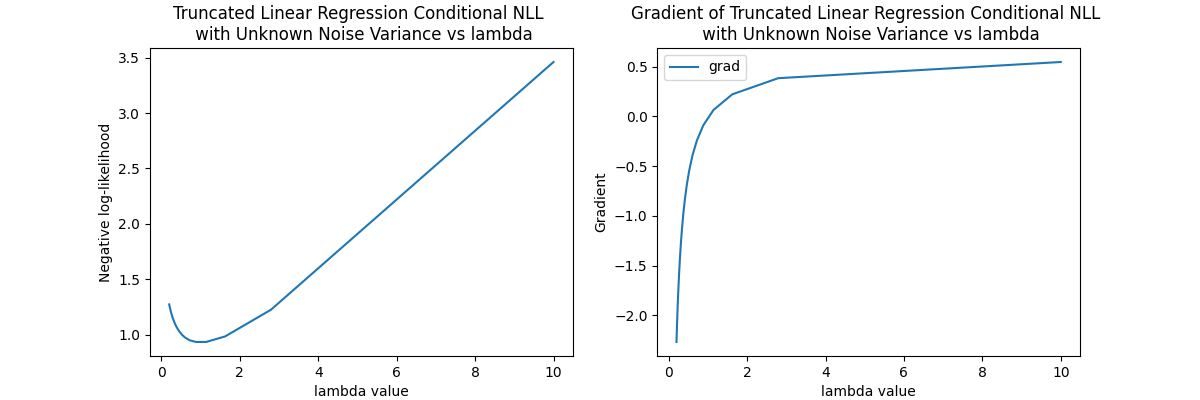

In [8]:
vars_ = ch.linspace(.1, 5, 20)
global PHAT
PHAT = ch.Tensor()

losses = ch.Tensor([])
grads = ch.Tensor([])

for var in vars_: 
    loss, pred_grad, lambda_grad = trunc_mse(X_trunc @ W.reshape(1, 1), Y_trunc, 1/ch.Tensor([[var]]), phi)
    losses = ch.cat([losses, loss[...,None].mean(0).detach()])
    grads = ch.cat([grads, lambda_grad.sum(0)])
    
# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(1.0/vars_, losses)
ax1.set_xlabel("lambda value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs lambda")

ax2.plot(1.0/vars_, grads, label="grad")
# ax2.plot(1./vars_, PHAT.mean(1).flatten(), label="p_hat")
ax2.set_xlabel("lambda value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs lambda")
ax2.legend()

plt.show()

/home/patroklos/base/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_139930/3238730500.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  Z[i, j] = loss


Ground truth: w=1.000, var=1.000
Minimum found: w=0.825, w0=1.067, loss=0.931

Loss at ground truth: 0.932
Loss at minimum: 0.931
Difference: 0.002


<IPython.core.display.Javascript object>


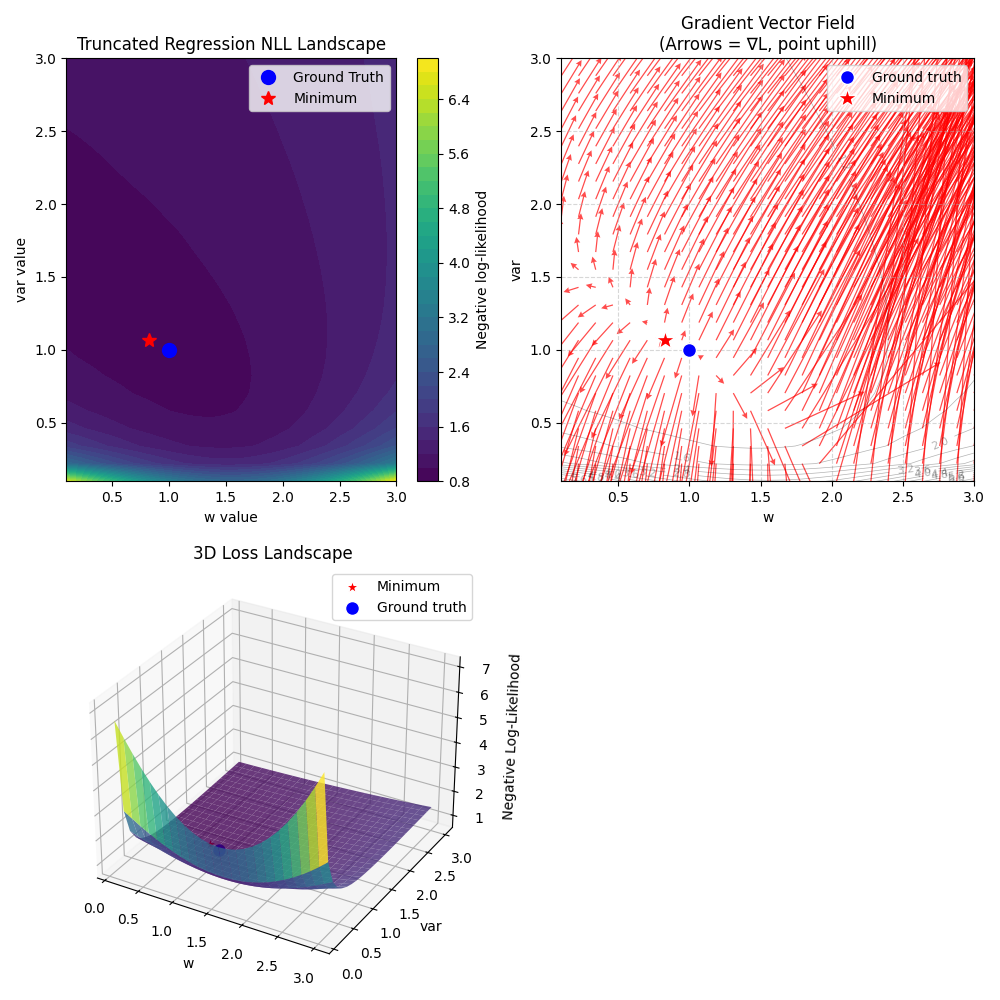

In [9]:
# === Parameter grids ===
W_values = ch.linspace(.1, 3, 25)
VAR_values = ch.linspace(.1, 3, 25)
W_, VAR_ = ch.meshgrid(W_values, VAR_values)

X_trunc_ones = ch.cat([X_trunc, ch.ones_like(X_trunc)], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(W_)
GRAD_W = ch.zeros_like(W_)
GRAD_VAR = ch.zeros_like(VAR_)
for i in range(len(W_values)):
    for j in range(len(VAR_values)):
        trunc_pred = X_trunc @ W_[i, j].reshape(1, 1)
        loss, pred_grad, lambda_grad = trunc_mse(trunc_pred, Y_trunc, 1/VAR_[i, j], phi)
    
        grad_ = (pred_grad * X_trunc).sum(0)

        Z[i, j] = loss
        GRAD_W[i, j] = grad_
        dlambda_dvar = -1.0 / VAR_[i, j].pow(2)
        grad_var = lambda_grad * dlambda_dvar
        GRAD_VAR[i, j] = grad_var
    
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W_min, VAR_min = W_[min_idx], VAR_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w={W.item():.3f}, var={ch.ones(1, 1).item():.3f}")
print(f"Minimum found: w={W_min:.3f}, w0={VAR_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse((X_trunc @ W.reshape(1, 1)), Y_trunc, ch.ones(1, 1), phi)[0].item()
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W_, VAR_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("var value")

# mark the ground truth
ax1.plot(W.item(), ch.ones(1).item(), 'bo', markersize=10, label="Ground Truth")
ax1.plot(W_min.item(), VAR_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W_, VAR_, GRAD_W, GRAD_VAR,
               color='red', alpha=0.7, width=0.003, scale=1, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W_, VAR_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(W.item(), ch.ones(1).item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W_min, VAR_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w')
ax4.set_ylabel('var')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W_, VAR_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W_min], [VAR_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([W.item()], [ch.ones(1, 1).sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w')
ax3.set_ylabel('var')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

# Run Procedure - 1 Dimension No Intercept

In [10]:
W = ch.ones(1)
NOISE_VAR = 1.0
print(f'groud truth W:\n {W}')

X = ch.rand(5000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + NOISE_VAR**.5 * ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 5000
W fit:
 [1.0230314]


In [11]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.694
trunc lin reg W:
 [[1.6194514]]


In [12]:
from torch.nn import MSELoss
mse_loss = MSELoss()

gt_norm = LinearRegression(fit_intercept=False)
gt_norm.fit(X, Y)
gt_ = ch.from_numpy(gt_norm.coef_.flatten())
print(f'ground truth lin reg: {gt_}')
gt_noise_var = (ch.from_numpy(gt_norm.predict(X)) - Y).var(0)
print(f'gt noise var: {gt_noise_var}')

# calculate empirical noise variance for regression 
emp_ = ch.from_numpy(trunc_lin_reg.coef_.flatten())
emp_noise_var = (ch.from_numpy(trunc_lin_reg.predict(X_trunc)) - Y_trunc).var(0)
print(f'empirical weights: {emp_}')
print(f'empricial noise variance: {emp_noise_var}')
emp_mse_loss = mse_loss(emp_, gt_)
emp_var_l1 = ch.abs(emp_noise_var - ch.Tensor([NOISE_VAR]))
print(f'emp mse loss: {emp_mse_loss}')
print(f'emp noise var l1: {emp_var_l1}')

ground truth lin reg: tensor([1.0230])
gt noise var: 1.0011274814605713
empirical weights: tensor([1.6195])
empricial noise variance: tensor([0.5939])
emp mse loss: 0.35571688413619995
emp noise var l1: tensor([0.4061])


In [22]:
from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

y_trunc_scale = Y_trunc / (emp_noise_var ** .5)
# train algorithm
args = Parameters({'epochs': 5,
                    'lr': 1e-1,
                    'batch_size': 10,
                    'trials': 1,
                    'verbose': True,
                    'var_lr': 1e-2}) 
trunc_reg = TruncatedLinearRegression(args, 
                                      phi,
                                      alpha, 
                                      fit_intercept=False)
trunc_reg.fit(X_trunc, y_trunc_scale)

trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': False}
Epoch 1 - Loss: 1.190718173980713
Epoch 2 - Loss: 1.1820871829986572
Epoch 3 - Loss: 1.179107666015625
Epoch 4 - Loss: 1.1794339418411255
Epoch 5 - Loss: 1.178093671798706


TruncatedLinearRegression()

In [23]:
delphi_noise_var = trunc_reg.best_variance_ * emp_noise_var
delphi_coef = trunc_reg.best_coef_ * emp_noise_var ** .5
delphi_empirical_weight = trunc_reg.emp_weight
print(f'delphi noise var: {delphi_noise_var}')
print(f'delphi coef: {delphi_coef}')
print(f'delphi empirical weight: {delphi_empirical_weight}')

delphi_mse_loss = mse_loss(delphi_coef, gt_)
delphi_var_l1 = ch.abs(delphi_noise_var - gt_noise_var)
print(f'delphi mse loss: {delphi_mse_loss}')
print(f'delphi var l1: {delphi_var_l1}')

delphi noise var: tensor([0.8745])
delphi coef: tensor([[1.0766]])
delphi empirical weight: tensor([[2.0965]])
delphi mse loss: 0.0028679093811661005
delphi var l1: tensor([0.1266])


In [42]:
trunc_reg.emp_noise_var

tensor([[0.6204]])

Ground truth: w=1.000, var=1.000
Minimum found: w=0.946, w0=1.067, loss=0.000

Loss at ground truth: 0.000
Loss at minimum: 0.000
Difference: 0.000


<IPython.core.display.Javascript object>


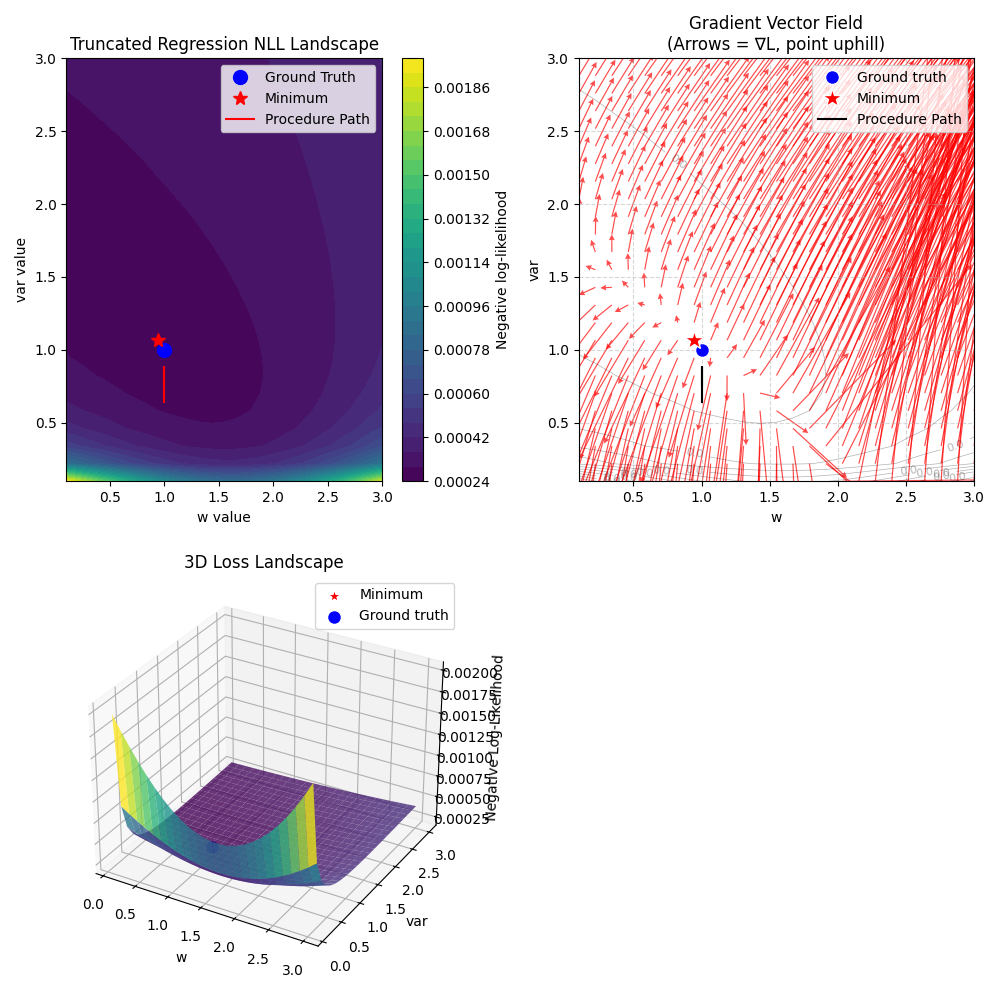

In [64]:
param_history = trunc_reg.trainer.param_history.detach()
v_history = param_history[:,0]
lambda_history = param_history[:,1]
var_history = 1/lambda_history
weight_history = (trunc_reg.emp_noise_var * v_history).squeeze(0)

loss_history = trunc_reg.trainer.loss_history.detach()

# === Parameter grids ===
W_values = ch.linspace(.1, 3, 25)
VAR_values = ch.linspace(.1, 3, 25)
W_, VAR_ = ch.meshgrid(W_values, VAR_values)

X_trunc_ones = ch.cat([X_trunc, ch.ones_like(X_trunc)], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(W_)
GRAD_W = ch.zeros_like(W_)
GRAD_VAR = ch.zeros_like(VAR_)
for i in range(len(W_values)):
    for j in range(len(VAR_values)):
        trunc_pred = X_trunc @ W_[i, j].reshape(1, 1)
        loss, pred_grad, lambda_grad = trunc_mse(trunc_pred, Y_trunc, 1/VAR_[i, j], phi)
    
        grad_ = (pred_grad * X_trunc).sum(0)

        Z[i, j] = loss
        GRAD_W[i, j] = grad_
        dlambda_dvar = -1.0 / VAR_[i, j].pow(2)
        grad_var = lambda_grad * dlambda_dvar
        GRAD_VAR[i, j] = grad_var
    
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W_min, VAR_min = W_[min_idx], VAR_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w={W.item():.3f}, var={ch.ones(1, 1).item():.3f}")
print(f"Minimum found: w={W_min:.3f}, w0={VAR_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse((X_trunc @ W.reshape(1, 1)), Y_trunc, ch.ones(1, 1), phi)[0].item()
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W_, VAR_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("var value")

# mark the ground truth
ax1.plot(W.item(), ch.ones(1).item(), 'bo', markersize=10, label="Ground Truth")
ax1.plot(W_min.item(), VAR_min.item(), 'r*', markersize=10, label="Minimum")
ax1.plot(weight_history, var_history, color="r", label="Procedure Path")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W_, VAR_, GRAD_W, GRAD_VAR,
               color='red', alpha=0.7, width=0.003, scale=1, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W_, VAR_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(W.item(), ch.ones(1).item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W_min, VAR_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax4.plot(weight_history, var_history, color="black", label="Procedure Path")

ax4.set_xlabel('w')
ax4.set_ylabel('var')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W_, VAR_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W_min], [VAR_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([W.item()], [ch.ones(1, 1).sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w')
ax3.set_ylabel('var')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

In [72]:
min_dist_var = var_history[ch.abs(var_history - NOISE_VAR).argmin()]
best_var = trunc_reg.best_variance_

In [104]:
w_min_dist_var = (trunc_reg.v*min_dist_var).detach()
w_best = (trunc_reg.v*best_var).detach()
loss, pred_grad, lambda_grad = trunc_mse((X_trunc@w_min_dist_var), Y_trunc, min_dist_var, phi)
loss_best, pred_grad_best, lambda_grad_best = trunc_mse((X_trunc@w_best), Y_trunc, best_var, phi)

In [105]:
print(f'loss: {loss}')
print(f'best loss: {loss_best}')

loss: tensor([0.0003], grad_fn=<MeanBackward1>)
best loss: tensor([0.0003], grad_fn=<MeanBackward1>)


In [106]:
print(f'pred grad: {pred_grad.sum()}')
print(f'pred grad best: {pred_grad_best.sum()}')
print(f'lambda grad: {lambda_grad.sum()}')
print(f'lambda grad best: {lambda_grad_best.sum()}')

pred grad: 0.15081727504730225
pred grad best: 0.1312633752822876
lambda grad: -0.644962728023529
lambda grad best: -0.6925110816955566
